# 0. Setup

In [2]:
from pathlib import Path
import pandas as pd, numpy as np, re

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 200)

ROOT = Path.cwd().parent          # notebooks/ -> iac-paper/
RAW  = ROOT / "data" / "raw"
PROC = ROOT / "data" / "processed"
FIGS = ROOT / "outputs" / "figures"

FAO      = RAW / "faostat"
APPEEARS = RAW / "appeears"
GISTEMP  = RAW / "gistemp"
VHP      = RAW / "vhp"
CHIRPS   = RAW / "chirps"

for p in (PROC, FIGS, ROOT/"outputs"/"tables"):
    p.mkdir(parents=True, exist_ok=True)


In [3]:
import matplotlib.pyplot as plt

plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 300,
    "font.size": 10, "axes.grid": True,
    "grid.alpha": 0.3, "axes.spines.top": False,
    "axes.spines.right": False,
})

def save(fig, name):
    fig.tight_layout()
    fig.savefig(FIGS / f"{name}.png", bbox_inches="tight")
    print("saved:", name)

# 1. Load Raw Data

## 1.1 FAOSTAT

In [4]:
def read_fao(path):
    try:
        return pd.read_csv(path, encoding="utf-8-sig", low_memory=False)
    except UnicodeDecodeError:
        return pd.read_csv(path, encoding="latin-1", low_memory=False)

et = read_fao(FAO / "Environment_Temperature_change_E_Asia" / "Environment_Temperature_change_E_Asia_NOFLAG.csv")
qcl = read_fao(FAO / "Production_Crops_Livestock_E_Asia" / "Production_Crops_Livestock_E_Asia_NOFLAG.csv")
rl  = read_fao(FAO / "Inputs_LandUse_E_Asia" / "Inputs_LandUse_E_Asia_NOFLAG.csv")

print([a for a in qcl["Area"].unique() if a.startswith("T")])

['Tajikistan', 'Thailand', 'Timor-Leste', 'Türkiye', 'Turkmenistan']


## 1.2 APPEEARS

In [5]:
lst  = pd.read_csv(APPEEARS / "IAC-MOD11A2-061-results.csv")
ndvi = pd.read_csv(APPEEARS / "IAC-MOD13A2-061-results.csv")
smap = pd.read_csv(APPEEARS / "IAC-SPL3SMP-E-006-results.csv")

for d in (lst, ndvi, smap):
    d["Date"]  = pd.to_datetime(d["Date"])
    d["Year"]  = d["Date"].dt.year
    d["Month"] = d["Date"].dt.month

print(lst.shape, ndvi.shape, smap.shape)

(23739, 21) (11899, 31) (76900, 17)


## 1.3 GISTEMP

In [6]:
zon = pd.read_csv(GISTEMP / "ZonAnn.Ts+dSST.csv")
print(zon.shape, zon.columns.tolist()[:8])

(146, 15) ['Year', 'Glob', 'NHem', 'SHem', '24N-90N', '24S-24N', '90S-24S', '64N-90N']


saved: fig1_gistemp_zonal


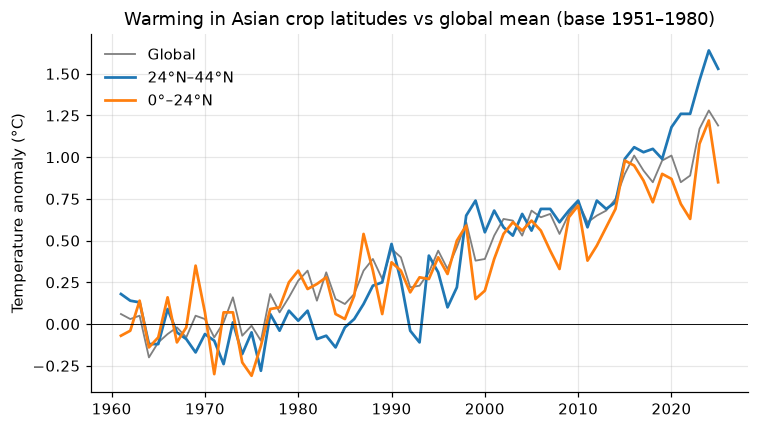

In [7]:
z = zon[zon["Year"] >= 1961]
fig, ax = plt.subplots(figsize=(7,4))
ax.plot(z["Year"], z["Glob"], color="gray", lw=1.2, label="Global")
ax.plot(z["Year"], z["24N-44N"], lw=1.8, label="24°N–44°N")
ax.plot(z["Year"], z["EQU-24N"], lw=1.8, label="0°–24°N")
ax.axhline(0, color="k", lw=0.6)
ax.set_ylabel("Temperature anomaly (°C)")
ax.set_title("Warming in Asian crop latitudes vs global mean (base 1951–1980)")
ax.legend(frameon=False)
save(fig, "fig1_gistemp_zonal")

## 1.4 VHP parser function

In [8]:
def read_vhp(path):
    text = Path(path).read_text(errors="ignore")
    m = re.search(r"Province=\s*\d+:\s*([^,]+)", text.splitlines()[0])
    province = m.group(1).strip() if m else Path(path).stem

    rows = []
    for L in text.splitlines():
        L = re.sub(r"<[^>]+>", "", L).strip()
        p = [x.strip() for x in L.split(",") if x.strip() != ""]
        if len(p) >= 7 and p[0].isdigit() and len(p[0]) == 4:
            rows.append(p[:7])

    df = pd.DataFrame(rows, columns=["Year","Week","SMN","SMT","VCI","TCI","VHI"]).astype(float)
    df[["Year","Week"]] = df[["Year","Week"]].astype(int)
    df = df.replace(-1.0, pd.NA).dropna(subset=["VHI"])
    df["Category"] = Path(path).stem.split("_")[0]
    df["Province"] = province
    df["Month"]    = ((df["Week"] - 1) * 7 // 30 + 1).clip(1, 12)
    return df

## 1.5 VHP cached

In [9]:
vhp_cache = PROC / "vhp_long.csv"
if vhp_cache.exists():
    vhp = pd.read_csv(vhp_cache)
    print("cached:", vhp.shape)
else:
    vhp = pd.concat([read_vhp(f) for f in sorted(VHP.glob("*.csv"))],
                    ignore_index=True)
    vhp.to_csv(vhp_cache, index=False)
    print("parsed:", vhp.shape)

cached: (124905, 10)


## 1.6 CHIRPS (cached)

In [10]:
ch_cache = PROC / "chirps_points.csv"
if ch_cache.exists():
    chirps = pd.read_csv(ch_cache)
    print("cached:", chirps.shape)
elif any(CHIRPS.glob("*.tif")):
    import rasterio
    pts = pd.read_csv(APPEEARS / "appeears_points.csv")
    coords = list(zip(pts["Longitude"], pts["Latitude"]))
    rows = []
    for f in sorted(CHIRPS.glob("*.tif")):
        yy, mm = f.stem.split(".")[-2:]
        with rasterio.open(f) as src:
            vals = [v[0] for v in src.sample(coords)]
        for (_, p), v in zip(pts.iterrows(), vals):
            rows.append({"Category": p["Category"], "Year": int(yy),
                         "Month": int(mm), "precip_mm": v})
    chirps = pd.DataFrame(rows)
    chirps.loc[chirps["precip_mm"] < 0, "precip_mm"] = pd.NA
    chirps.to_csv(ch_cache, index=False)
    print("sampled:", chirps.shape)
else:
    chirps = None
    print("no CHIRPS rasters yet — skipping")

cached: (2700, 4)


## 1.7 report

In [11]:
for _name, _d in [("et",et),("qcl",qcl),("rl",rl),("lst",lst),("ndvi",ndvi),
                  ("smap",smap),("zon",zon),("vhp",vhp),("chirps",chirps)]:
    print(f"{_name:7s} {'None' if _d is None else str(_d.shape)}")

et      (1734, 73)
qcl     (15412, 73)
rl      (1996, 73)
lst     (23739, 21)
ndvi    (11899, 31)
smap    (76900, 17)
zon     (146, 15)
vhp     (124905, 10)
chirps  (2700, 4)


## INSPECT STRINGS

In [12]:
print("ET Element:", et["Element"].unique())
print("ET Months: ", list(et["Months"].unique()))
print("QCL Element:", qcl["Element"].unique())
print("crops:", [i for i in qcl["Item"].unique()
                 if any(k in str(i).lower() for k in ["rice","wheat","maize"])])

ET Element: <ArrowStringArray>
['Temperature change', 'Standard Deviation']
Length: 2, dtype: str
ET Months:  ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December', 'Dec–Jan–Feb', 'Mar–Apr–May', 'Jun–Jul–Aug', 'Sep–Oct–Nov', 'Meteorological year']
QCL Element: <ArrowStringArray>
['Area harvested', 'Yield', 'Production', 'Stocks', 'Producing Animals/Slaughtered', 'Yield/Carcass Weight', 'Laying', 'Milk Animals']
Length: 8, dtype: str
crops: ['Maize (corn)', 'Rice', 'Wheat', 'Oil of maize', 'Buckwheat', 'Green corn (maize)']


In [13]:
print(vhp.groupby("Category").agg(
    provinces=("Province","nunique"), rows=("VHI","size"),
    first=("Year","min"), last=("Year","max")))

          provinces   rows  first  last
Category                               
BGD               3   6813   1982  2026
CHN               6  13626   1982  2026
IDN               3   6813   1982  2026
IND               6  13626   1982  2026
IRN               4   9084   1982  2026
JPN               4   9084   1982  2026
KAZ               3   6813   1982  2026
KHM               3   6813   1982  2026
LKA               1   2271   1982  2026
MMR               3   6813   1982  2026
NPL               1   2271   1982  2026
PAK               1   2271   1982  2026
PHL               4   9084   1982  2026
THA               7  15897   1982  2026
TUR               4   9084   1982  2026
VNM               2   4542   1982  2026


# BUILD PANEL

In [14]:
def to_long(df):
    ycols = [c for c in df.columns
             if len(c)==5 and c.startswith("Y") and c[1:].isdigit()]
    if not ycols: return df
    idc = [c for c in df.columns if c not in ycols]
    out = df.melt(id_vars=idc, value_vars=ycols, var_name="Year", value_name="Value")
    out["Year"] = out["Year"].str[1:].astype(int)
    return out.dropna(subset=["Value"])

print("BEFORE :", qcl.shape, "| year cols:", [c for c in qcl.columns if c.startswith("Y")][:3])
etL, qclL, rlL = to_long(et), to_long(qcl), to_long(rl)
print("AFTER  :", qclL.shape, "| now has Year column")
display(qclL.head(3))

BEFORE : (15412, 73) | year cols: ['Y1961', 'Y1962', 'Y1963']
AFTER  : (805583, 11) | now has Year column


,Area Code,Area Code (M49),Area,Item Code,Item Code (CPC),Item,Element Code,Element,Unit,Year,Value
0,2,'004,Afghanistan,221,'01371,"Almonds, in shell",5312,Area harvested,ha,1961,0.0
2,2,'004,Afghanistan,221,'01371,"Almonds, in shell",5510,Production,t,1961,0.0
6,2,'004,Afghanistan,515,'01341,Apples,5312,Area harvested,ha,1961,2220.0


In [15]:
CROPS = ["Rice", "Wheat", "Maize (corn)"]
DROP  = ["China", "China, Taiwan Province of",
         "China, Hong Kong SAR", "China, Macao SAR"]

print("BEFORE:", qclL.shape, "|", qclL['Item'].nunique(), "items,",
      qclL['Element'].nunique(), "elements")

y = qclL[(qclL["Element"]=="Yield") & (qclL["Item"].isin(CROPS))]
print("after element+crop filter:", y.shape)

y = y[~y["Area"].isin(DROP)]
print("after dropping China aggregates:", y.shape)

y = y[["Area","Item","Year","Value"]].rename(columns={"Value":"yield"})
y = y[y["Year"] <= 2024]
print("AFTER :", y.shape)
display(y.head(3))

BEFORE: (805583, 11) | 285 items, 8 elements
after element+crop filter: (6225, 11)
after dropping China aggregates: (6003, 11)
AFTER : (6003, 4)


,Area,Item,Year,yield
65,Afghanistan,Maize (corn),1961,1400.0
169,Afghanistan,Rice,1961,1519.0
203,Afghanistan,Wheat,1961,1022.0


In [16]:
def detrend(g, deg=2):
    g = g.sort_values("Year")
    g = g[g["yield"] > 0]
    if len(g) < 15:
        return None
    ly = np.log(g["yield"])
    g["yield_anom"] = 100 * (ly - np.polyval(np.polyfit(g["Year"], ly, deg), g["Year"]))
    return g

before = y.shape
y = pd.concat([d for _, g in y.groupby(["Area","Item"])
               if (d := detrend(g.copy())) is not None], ignore_index=True)
print("BEFORE:", before, "-> AFTER:", y.shape,
      f"({before[0]-y.shape[0]} rows dropped: series under 15 yrs)")

ex = y[(y.Area=="India") & (y.Item=="Wheat")].sort_values("yield_anom")
print("\nIndia wheat — worst 3 and best 3 years:")
display(pd.concat([ex.head(3), ex.tail(3)])[["Year","yield","yield_anom"]])

BEFORE: (6003, 4) -> AFTER: (6003, 5) (0 rows dropped: series under 15 yrs)

India wheat — worst 3 and best 3 years:


,Year,yield,yield_anom
1578,1964,729.9,-19.158903
1629,2015,2749.6,-15.341167
1580,1966,826.8,-15.013597
1576,1962,889.6,9.214595
1585,1971,1306.6,11.115336
1586,1972,1379.9,12.847103


In [17]:
def get_temp(label, name):
    t = etL[(etL["Element"]=="Temperature change") & (etL["Months"]==label)]
    return t[["Area","Year","Value"]].rename(columns={"Value":name})

mam = [m for m in etL["Months"].unique() if m.startswith("Mar")][0]
jja = [m for m in etL["Months"].unique() if m.startswith("Jun")][0]

print("BEFORE:", y.shape, list(y.columns))
panel = (y.merge(get_temp("Meteorological year","temp_anom"), on=["Area","Year"], how="left")
           .merge(get_temp(mam,"temp_mam"), on=["Area","Year"], how="left")
           .merge(get_temp(jja,"temp_jja"), on=["Area","Year"], how="left"))
print("AFTER :", panel.shape, list(panel.columns))
print("temp matched:", panel['temp_anom'].notna().sum(), "of", len(panel))
display(panel.head(3))

BEFORE: (6003, 5) ['Area', 'Item', 'Year', 'yield', 'yield_anom']
AFTER : (6003, 8) ['Area', 'Item', 'Year', 'yield', 'yield_anom', 'temp_anom', 'temp_mam', 'temp_jja']
temp matched: 5909 of 6003


,Area,Item,Year,yield,yield_anom,temp_anom,temp_mam,temp_jja
0,Afghanistan,Maize (corn),1961,1400.0,-5.236950,-0.098,0.490,-0.115
1,Afghanistan,Maize (corn),1962,1400.0,-5.527885,-0.149,1.310,-1.143
2,Afghanistan,Maize (corn),1963,1426.0,-3.987045,0.864,0.387,1.122


In [18]:
FAO_NAME = {"IND":"India","PAK":"Pakistan","BGD":"Bangladesh","NPL":"Nepal",
            "LKA":"Sri Lanka","THA":"Thailand","VNM":"Viet Nam","IDN":"Indonesia",
            "PHL":"Philippines","MMR":"Myanmar","KHM":"Cambodia",
            "CHN":"China, mainland","JPN":"Japan","KAZ":"Kazakhstan",
            "IRN":"Iran (Islamic Republic of)","TUR":"Türkiye"}

GROUP = {"South":["IND","PAK","BGD","NPL","LKA"],
         "Southeast":["THA","VNM","IDN","PHL","MMR","KHM"],
         "East":["CHN","JPN"],
         "CentralWest":["KAZ","IRN","TUR"]}
CODE_SUB = {c:g for g,cs in GROUP.items() for c in cs}

missing = [v for v in FAO_NAME.values() if v not in set(panel["Area"])]
print("NOT FOUND:", missing if missing else "none — all 16 matched")

panel["Category"]  = panel["Area"].map({v:k for k,v in FAO_NAME.items()})
panel["Subregion"] = panel["Category"].map(CODE_SUB)

print(panel.groupby("Subregion").size())

# ---- freeze the base table ----
panel_base = panel.copy()
print("panel_base:", panel_base.shape)

NOT FOUND: none — all 16 matched
Subregion
CentralWest    483
East           384
South          896
Southeast      871
dtype: int64
panel_base: (6003, 10)


In [19]:
print([a for a in panel["Area"].unique() if "urk" in a.lower() or "ürk" in a.lower()])
print([a for a in panel["Area"].unique() if a.startswith("T")])

['Turkmenistan', 'Türkiye']
['Tajikistan', 'Thailand', 'Timor-Leste', 'Turkmenistan', 'Türkiye']


In [20]:
SEASON = {"Rice":[6,7,8,9,10], "Wheat":[2,3,4], "Maize (corn)":[6,7,8,9]}

def vhp_block(months):
    s = vhp[vhp["Month"].isin(months)]
    out = s.groupby(["Category","Year"])[["VCI","TCI","VHI"]].mean().reset_index()
    dr = (s.assign(d=s["VCI"] < 40)
            .groupby(["Category","Year"])["d"]
            .mean().reset_index(name="drought_frac"))
    out = out.merge(dr, on=["Category","Year"])
    for c in ["VCI","TCI","VHI","drought_frac"]:
        out[c + "_anom"] = out[c] - out.groupby("Category")[c].transform("mean")
    return out

print("VHP weekly rows:", len(vhp))
w = vhp_block(SEASON["Wheat"])
print("-> wheat season:", w.shape)
display(w.head(3))

VHP weekly rows: 124905
-> wheat season: (720, 10)


,Category,Year,VCI,TCI,VHI,drought_frac,VCI_anom,TCI_anom,VHI_anom,drought_frac_anom
0,BGD,1982,22.378718,40.003846,31.190769,1.000000,-35.750430,-15.645671,-25.701772,0.788025
1,BGD,1983,15.668462,47.850513,31.758974,1.000000,-42.460686,-7.799005,-25.133567,0.788025
2,BGD,1984,27.136154,48.389231,37.762051,0.794872,-30.992994,-7.260287,-19.130490,0.582896


In [21]:
print(vhp_block([2,3,4]).columns.tolist())

['Category', 'Year', 'VCI', 'TCI', 'VHI', 'drought_frac', 'VCI_anom', 'TCI_anom', 'VHI_anom', 'drought_frac_anom']


In [22]:
w = vhp_block(SEASON["Wheat"])
print(w.groupby("Category")["drought_frac"].mean().sort_values(ascending=False).round(3))

Category
KAZ    0.451
KHM    0.437
TUR    0.324
VNM    0.318
CHN    0.313
THA    0.311
MMR    0.302
IRN    0.288
JPN    0.276
IND    0.238
LKA    0.232
NPL    0.232
PAK    0.215
BGD    0.212
IDN    0.183
PHL    0.166
Name: drought_frac, dtype: float64


In [23]:
rice_vhp = vhp_block(SEASON["Rice"])
print(rice_vhp.groupby("Category")["drought_frac"].mean().sort_values(ascending=False).round(3))

Category
IRN    0.411
VNM    0.305
TUR    0.270
KHM    0.268
KAZ    0.267
PAK    0.219
LKA    0.214
NPL    0.210
THA    0.206
PHL    0.202
BGD    0.199
IND    0.187
IDN    0.172
MMR    0.168
JPN    0.161
CHN    0.155
Name: drought_frac, dtype: float64


In [24]:
s = vhp[vhp["Month"].isin(SEASON["Rice"])]
print(s.groupby("Category")[["VCI","TCI","VHI"]].mean().round(1)
       .sort_values("VHI").head(8))

           VCI   TCI   VHI
Category                  
VNM       47.9  36.4  42.1
KHM       50.7  33.8  42.2
BGD       54.2  32.6  43.3
IRN       44.2  42.9  43.6
PHL       53.9  36.9  45.4
NPL       49.4  42.0  45.6
MMR       54.4  37.9  46.1
IDN       54.0  39.1  46.6


In [25]:
LSTC  = "MOD11A2_061_LST_Day_1km"
NDVIC = "MOD13A2_061__1_km_16_days_NDVI"

print("RAW LST :", lst[LSTC].describe()[["mean","min","max"]].round(1).to_dict())
print("RAW NDVI:", ndvi[NDVIC].describe()[["mean","min","max"]].round(3).to_dict())

lst_c = lst.copy()
lst_c = lst_c[lst_c[LSTC] > 100]
lst_c["LST_C"] = lst_c[LSTC] - 273.15
lst_c = lst_c[lst_c["MOD11A2_061_QC_Day_MODLAND"].isin(["0b00","0b01"])]
lst_c = lst_c[(lst_c["LST_C"] > -25) & (lst_c["LST_C"] < 70)]

ndvi_c = ndvi.copy()
ndvi_c["NDVI"] = ndvi_c[NDVIC]
ndvi_c = ndvi_c[(ndvi_c["NDVI"] > -0.2) & (ndvi_c["NDVI"] <= 1.0)]
print("LST:", lst_c.shape, "| NDVI:", ndvi_c.shape)

RAW LST : {'mean': 240.9, 'min': 0.0, 'max': 323.1}
RAW NDVI: {'mean': 0.43, 'min': -0.179, 'max': 0.941}
LST: (19091, 22) | NDVI: (11899, 32)


In [26]:
print(lst["MOD11A2_061_QC_Day_MODLAND"].value_counts().head(10))
print(lst["MOD11A2_061_QC_Day_MODLAND"].dtype)

MOD11A2_061_QC_Day_MODLAND
0b01    11224
0b00     7877
0b10     4638
Name: count, dtype: int64
str


In [27]:
lst_c = lst.copy()
lst_c = lst_c[lst_c[LSTC] > 100]
lst_c["LST_C"] = lst_c[LSTC] - 273.15
lst_c = lst_c[lst_c["MOD11A2_061_QC_Day_MODLAND"].isin(["0b00","0b01"])]
lst_c = lst_c[(lst_c["LST_C"] > -25) & (lst_c["LST_C"] < 70)]
print("LST_C:", lst_c["LST_C"].describe()[["mean","min","max"]].round(1).to_dict(),
      "| rows:", len(lst_c))

ndvi_c = ndvi.copy()
ndvi_c["NDVI"] = ndvi_c[NDVIC]
ndvi_c = ndvi_c[(ndvi_c["NDVI"] > -0.2) & (ndvi_c["NDVI"] <= 1.0)]
print("NDVI :", len(ndvi_c), "rows")

LST_C: {'mean': 26.3, 'min': -24.4, 'max': 50.0} | rows: 19091
NDVI : 11899 rows


## 3.8 — Build panel
Merges VHP, MODIS LST/NDVI, and CHIRPS onto the FAOSTAT base.
Reads `panel_base`, writes `panel` → `data/processed/panel.csv`.
Safe to re-run.

In [28]:
PTS_TO_CODE = {
    "India":"IND", "Pakistan":"PAK", "Bangladesh":"BGD", "Nepal":"NPL",
    "SriLanka":"LKA", "Thailand":"THA", "VietNam":"VNM", "Indonesia":"IDN",
    "Philippines":"PHL", "Myanmar":"MMR", "Cambodia":"KHM", "China":"CHN",
    "Japan":"JPN", "Kazakhstan":"KAZ", "Iran":"IRN", "Turkiye":"TUR",
}

for _df in (lst_c, ndvi_c, smap):
    _df["Category"] = _df["Category"].replace(PTS_TO_CODE)

if chirps is not None:
    chirps["Category"] = chirps["Category"].replace(PTS_TO_CODE)

SEASON = {"Rice":[6,7,8,9,10], "Wheat":[2,3,4], "Maize (corn)":[6,7,8,9]}


def _anomalize(out, cols):
    for c in cols:
        out[c + "_anom"] = out[c] - out.groupby("Category")[c].transform("mean")
    return out


def _vhp(months):
    s = vhp[vhp["Month"].isin(months)]
    out = s.groupby(["Category","Year"])[["VCI","TCI","VHI"]].mean().reset_index()
    dr = (s.assign(d=s["VCI"] < 40)
            .groupby(["Category","Year"])["d"].mean()
            .reset_index(name="drought_frac"))
    out = out.merge(dr, on=["Category","Year"])
    return _anomalize(out, ["VCI","TCI","VHI","drought_frac"])


def _season(df, col, months):
    s = df[df["Month"].isin(months)]
    out = s.groupby(["Category","Year"])[[col]].mean().reset_index()
    return _anomalize(out, [col])


def _chirps(months):
    s = chirps[chirps["Month"].isin(months)]
    out = s.groupby(["Category","Year"])["precip_mm"].sum().reset_index()
    return _anomalize(out, ["precip_mm"])


frames = []
for crop, months in SEASON.items():
    p  = panel_base[panel_base["Item"] == crop].copy()
    n0 = len(p)

    p = p.merge(_vhp(months),                     on=["Category","Year"], how="left")
    p = p.merge(_season(lst_c,  "LST_C", months), on=["Category","Year"], how="left")
    p = p.merge(_season(ndvi_c, "NDVI",  months), on=["Category","Year"], how="left")

    if chirps is not None:
        p = p.merge(_chirps(months),              on=["Category","Year"], how="left")

    print(f"{crop:14s} {n0:5d} -> {len(p):5d} | VCI {p['VCI_anom'].notna().sum():4d}"
          f" | LST {p['LST_C_anom'].notna().sum():4d}"
          f" | NDVI {p['NDVI_anom'].notna().sum():4d}"
          f" | precip {p['precip_mm_anom'].notna().sum() if 'precip_mm_anom' in p else 0:4d}")
    frames.append(p)

panel = pd.concat(frames, ignore_index=True)
panel.to_csv(PROC / "panel.csv", index=False)
print("\nFINAL:", panel.shape)

Rice            1797 ->  1797 | VCI  678 | LST  400 | NDVI  400 | precip    0
Wheat           1929 ->  1929 | VCI  459 | LST  275 | NDVI  275 | precip  468
Maize (corn)    2277 ->  2277 | VCI  678 | LST  400 | NDVI  400 | precip    0

FINAL: (6003, 24)


# Analysis

## 4.1 Descriptive vulnerability

In [29]:
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt

plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 300, "font.size": 10,
    "axes.grid": True, "grid.alpha": 0.3,
    "axes.spines.top": False, "axes.spines.right": False,
})

def save(fig, name):
    fig.tight_layout()
    fig.savefig(FIGS / f"{name}.png", bbox_inches="tight")
    print("saved:", name)

def run(df, formula, needs, cluster="Area"):
    """Fit OLS with country fixed effects and clustered SEs.
       `needs` = columns that must be non-null."""
    d = df.dropna(subset=needs + [cluster])
    if len(d) < 30:
        return None, d
    m = smf.ols(formula, data=d).fit(cov_type="cluster",
                                     cov_kwds={"groups": d[cluster]})
    return m, d

CROPS = ["Rice", "Wheat", "Maize (corn)"]
EO    = ["VCI_anom", "LST_C_anom", "NDVI_anom"]

panel = pd.read_csv(PROC / "panel.csv")
print(panel.shape)

(6003, 24)


In [30]:
vol = (panel.dropna(subset=["Subregion"])
       .groupby(["Subregion","Item"])
       .agg(n=("yield_anom","size"),
            sd=("yield_anom","std"),
            shock=("yield_anom", lambda s: (s < -10).mean()))
       .round(3).reset_index())
print(vol.to_string(index=False))

  Subregion         Item   n     sd  shock
CentralWest Maize (corn) 161 18.599  0.186
CentralWest         Rice 161  9.048  0.099
CentralWest        Wheat 161 14.863  0.199
       East Maize (corn) 128  8.341  0.078
       East         Rice 128  5.526  0.047
       East        Wheat 128 11.156  0.133
      South Maize (corn) 320 17.904  0.228
      South         Rice 320  7.949  0.103
      South        Wheat 256 11.335  0.137
  Southeast Maize (corn) 384 14.196  0.195
  Southeast         Rice 384  8.813  0.094
  Southeast        Wheat 103 21.766  0.330


In [31]:
print(f"{'Crop':14s} {'%/°C':>8s} {'SE':>7s} {'p':>8s} {'n':>6s}")
for crop in CROPS:
    m, d = run(panel[panel["Item"]==crop],
               "yield_anom ~ temp_anom + C(Area)",
               ["yield_anom","temp_anom"])
    if m is None:
        print(f"{crop:14s} insufficient data"); continue
    print(f"{crop:14s} {m.params['temp_anom']:8.2f} {m.bse['temp_anom']:7.2f}"
          f" {m.pvalues['temp_anom']:8.4f} {len(d):6d}")

Crop               %/°C      SE        p      n
Rice              -0.54    0.68   0.4308   1786
Wheat             -1.51    0.75   0.0430   1896
Maize (corn)      -1.14    0.69   0.1024   2227


In [32]:
print(f"{'Crop':14s} {'temp':>8s} {'precip':>10s} {'n':>6s}")
for crop in CROPS:
    m, d = run(panel[panel["Item"]==crop],
               "yield_anom ~ temp_anom + precip_mm_anom + C(Area)",
               ["yield_anom","temp_anom","precip_mm_anom"])
    if m is None:
        print(f"{crop:14s} no precipitation data (CHIRPS is Feb–Apr only)")
        continue
    print(f"{crop:14s} {m.params['temp_anom']:8.2f}"
          f" {m.params['precip_mm_anom']:10.4f} {len(d):6d}")

Crop               temp     precip      n
Rice           no precipitation data (CHIRPS is Feb–Apr only)
Wheat             -1.16     0.0019    468
Maize (corn)   no precipitation data (CHIRPS is Feb–Apr only)


In [33]:
print(f"{'Crop':14s} {'variable':12s} {'coef':>8s} {'R²':>8s} {'n':>6s}")
for crop, tvar in [("Wheat","temp_mam"), ("Rice","temp_jja"), ("Maize (corn)","temp_jja")]:
    sub = panel[panel["Item"]==crop].dropna(subset=["yield_anom","temp_anom",tvar])
    for v in ["temp_anom", tvar]:
        m, d = run(sub, f"yield_anom ~ {v} + C(Area)", ["yield_anom", v])
        if m is None: continue
        print(f"{crop:14s} {v:12s} {m.params[v]:8.2f} {m.rsquared:8.4f} {len(d):6d}")
    print()

Crop           variable         coef       R²      n
Wheat          temp_anom       -1.51   0.0022   1896
Wheat          temp_mam        -0.78   0.0027   1896

Rice           temp_anom       -0.54   0.0004   1783
Rice           temp_jja        -0.65   0.0009   1783

Maize (corn)   temp_anom       -1.14   0.0012   2223
Maize (corn)   temp_jja        -0.99   0.0014   2223



In [34]:
for crop in CROPS:
    sub = panel[panel["Item"]==crop].dropna(subset=["yield_anom","temp_anom","Subregion"])
    m = smf.ols("yield_anom ~ temp_anom * C(Subregion)", data=sub).fit(
        cov_type="cluster", cov_kwds={"groups": sub["Area"]})
    print(f"=== {crop} (n={len(sub)}) ===")
    for k in m.params.index:
        if "temp_anom" in k:
            print(f"  {k:44s} {m.params[k]:7.2f}  p={m.pvalues[k]:.3f}")
    print()

=== Rice (n=993) ===
  temp_anom                                      -1.03  p=0.003
  temp_anom:C(Subregion)[T.East]                  1.08  p=0.011
  temp_anom:C(Subregion)[T.South]                 1.02  p=0.234
  temp_anom:C(Subregion)[T.Southeast]            -0.46  p=0.528

=== Wheat (n=648) ===
  temp_anom                                       0.25  p=0.720
  temp_anom:C(Subregion)[T.East]                  0.02  p=0.989
  temp_anom:C(Subregion)[T.South]                -0.83  p=0.381
  temp_anom:C(Subregion)[T.Southeast]            -1.64  p=0.029

=== Maize (corn) (n=993) ===
  temp_anom                                      -2.05  p=0.000
  temp_anom:C(Subregion)[T.East]                  2.50  p=0.007
  temp_anom:C(Subregion)[T.South]                 0.45  p=0.628
  temp_anom:C(Subregion)[T.Southeast]            -0.87  p=0.497



In [35]:
res = []
for crop in CROPS:
    sub = panel[panel["Item"]==crop].dropna(
        subset=["yield_anom","temp_anom"] + EO + ["Area"])
    if len(sub) < 60:
        print(f"{crop:14s} n={len(sub)} — too few"); continue
    m1 = smf.ols("yield_anom ~ temp_anom + C(Area)", data=sub).fit()
    m2 = smf.ols("yield_anom ~ temp_anom + " + " + ".join(EO) + " + C(Area)",
                 data=sub).fit()
    f = m2.compare_f_test(m1)
    res.append({"crop":crop, "n":len(sub),
                "Climate only":m1.rsquared_adj, "Climate + EO":m2.rsquared_adj,
                "F":f[0], "p":f[1]})
    print(f"{crop:14s} n={len(sub):4d}  adjR² {m1.rsquared_adj:.3f} -> {m2.rsquared_adj:.3f}"
          f"  F={f[0]:5.2f} p={f[1]:.4f}")

eo_results = pd.DataFrame(res)
print(eo_results.round(3).to_string(index=False))

Rice           n= 400  adjR² 0.087 -> 0.087  F= 0.99 p=0.3988
Wheat          n= 275  adjR² -0.005 -> 0.016  F= 2.91 p=0.0350
Maize (corn)   n= 400  adjR² 0.164 -> 0.165  F= 1.19 p=0.3131
        crop   n  Climate only  Climate + EO     F     p
        Rice 400         0.087         0.087 0.987 0.399
       Wheat 275        -0.005         0.016 2.911 0.035
Maize (corn) 400         0.164         0.165 1.190 0.313


In [36]:
print("--- A: VCI only, full 1982+ sample ---")
for crop in CROPS:
    sub = panel[panel["Item"]==crop].dropna(
        subset=["yield_anom","temp_anom","VCI_anom","drought_frac_anom","Area"])
    m1 = smf.ols("yield_anom ~ temp_anom + C(Area)", data=sub).fit()
    m2 = smf.ols("yield_anom ~ temp_anom + VCI_anom + drought_frac_anom + C(Area)",
                 data=sub).fit()
    f = m2.compare_f_test(m1)
    print(f"{crop:14s} n={len(sub):4d}  adjR² {m1.rsquared_adj:.3f} -> {m2.rsquared_adj:.3f}"
          f"  F={f[0]:5.2f} p={f[1]:.4f}")

print("\n--- B: full EO block, no country FE ---")
for crop in CROPS:
    sub = panel[panel["Item"]==crop].dropna(
        subset=["yield_anom","temp_anom"] + EO + ["Area"])
    m1 = smf.ols("yield_anom ~ temp_anom", data=sub).fit()
    m2 = smf.ols("yield_anom ~ temp_anom + " + " + ".join(EO), data=sub).fit()
    f = m2.compare_f_test(m1)
    print(f"{crop:14s} n={len(sub):4d}  adjR² {m1.rsquared_adj:.3f} -> {m2.rsquared_adj:.3f}"
          f"  F={f[0]:5.2f} p={f[1]:.4f}")

--- A: VCI only, full 1982+ sample ---
Rice           n= 678  adjR² 0.002 -> 0.002  F= 1.07 p=0.3432
Wheat          n= 459  adjR² -0.020 -> -0.024  F= 0.03 p=0.9716
Maize (corn)   n= 678  adjR² -0.012 -> -0.003  F= 4.05 p=0.0178

--- B: full EO block, no country FE ---
Rice           n= 400  adjR² 0.057 -> 0.056  F= 0.79 p=0.5001
Wheat          n= 275  adjR² 0.004 -> 0.020  F= 2.50 p=0.0597
Maize (corn)   n= 400  adjR² 0.094 -> 0.098  F= 1.71 p=0.1652


        crop         sub   n      b     lo     hi     p
        Rice CentralWest 161 -1.029 -1.843 -0.215 0.013
        Rice        East 128  0.054 -0.583  0.691 0.869
        Rice       South 320 -0.006 -1.667  1.654 0.994
        Rice   Southeast 384 -1.488 -2.810 -0.166 0.027
       Wheat CentralWest 161  0.249 -1.337  1.835 0.758
       Wheat        East 128  0.267 -2.610  3.143 0.856
       Wheat       South 256 -0.582 -1.968  0.804 0.411
       Wheat   Southeast 103 -1.389 -2.129 -0.649 0.000
Maize (corn) CentralWest 161 -2.055 -3.237 -0.872 0.001
Maize (corn)        East 128  0.449 -1.631  2.528 0.672
Maize (corn)       South 320 -1.604 -3.254  0.047 0.057
Maize (corn)   Southeast 384 -2.926 -5.368 -0.483 0.019
saved: fig5_subregional


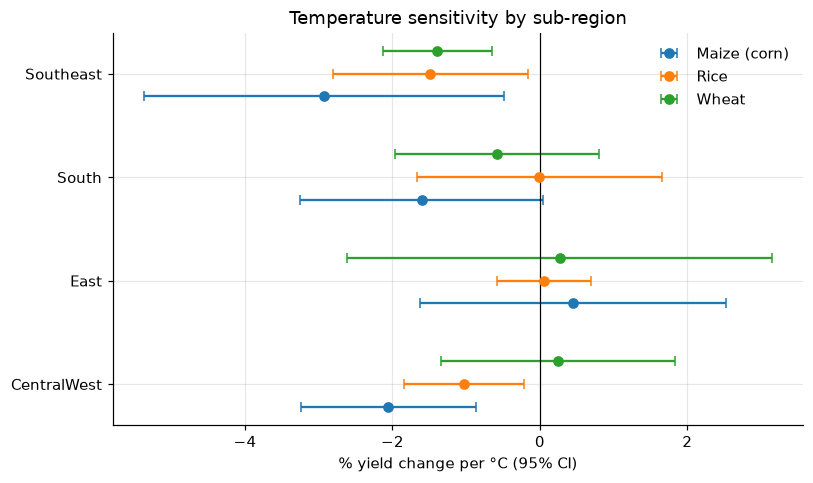

In [37]:
rows = []
for crop in CROPS:
    for sr in ["CentralWest","East","South","Southeast"]:
        s2 = panel[(panel["Item"]==crop) & (panel["Subregion"]==sr)].dropna(
            subset=["yield_anom","temp_anom"])
        if len(s2) < 40: continue
        m = smf.ols("yield_anom ~ temp_anom", data=s2).fit(
            cov_type="cluster", cov_kwds={"groups": s2["Area"]})
        ci = m.conf_int().loc["temp_anom"]
        rows.append({"crop":crop, "sub":sr, "n":len(s2),
                     "b":m.params["temp_anom"], "lo":ci[0], "hi":ci[1],
                     "p":m.pvalues["temp_anom"]})
sr_df = pd.DataFrame(rows)
print(sr_df.round(3).to_string(index=False))

fig, ax = plt.subplots(figsize=(7.5,4.5))
for i,(crop,g) in enumerate(sr_df.groupby("crop")):
    ypos = np.arange(len(g)) + (i-1)*0.22
    ax.errorbar(g["b"], ypos, xerr=[g["b"]-g["lo"], g["hi"]-g["b"]],
                fmt="o", capsize=3, label=crop)
ax.set_yticks(range(4)); ax.set_yticklabels(sr_df["sub"].unique())
ax.axvline(0, color="k", lw=0.8)
ax.set_xlabel("% yield change per °C (95% CI)")
ax.set_title("Temperature sensitivity by sub-region")
ax.legend(frameon=False)
save(fig, "fig5_subregional")

In [38]:
print("RL Elements:", rlL["Element"].unique())
print()
print("Items with 'irrig':", [i for i in rlL["Item"].unique() if "rrigat" in str(i)])
print()
print("Items with 'land':", [i for i in rlL["Item"].unique() if "and" in str(i)][:25])

RL Elements: <ArrowStringArray>
[                                              'Area',                                 'Share in Land area', 'Value of agricultural production (Int. $) per Area',
                         'Share in Agricultural land',                                    'Area per capita',                                  'Share in Cropland',
                     'Carbon stock in living biomass',                               'Share in Forest land']
Length: 8, dtype: str

Items with 'irrig': ['Land area equipped for irrigation', 'Agriculture area actually irrigated', 'Cropland area actually irrigated', 'Land area actually irrigated', 'Forestry area actually irrigated']

Items with 'land': ['Land area', 'Agricultural land', 'Cropland', 'Arable land', 'Permanent meadows and pastures', 'Inland waters', 'Land area equipped for irrigation', 'Forest land', 'Other land', 'Temporary meadows and pastures', 'Cropland area actually irrigated', 'Cropland area under protective cover', 

In [39]:
ir = rlL[rlL["Item"].str.contains("rrigat", na=False)]
print(ir.groupby(["Item","Element"]).size().to_string())
print()
print("years:", ir["Year"].min(), "-", ir["Year"].max())
print("countries:", ir["Area"].nunique())

Item                                 Element                   
Agriculture area actually irrigated  Area                           469
                                     Share in Agricultural land     469
Cropland area actually irrigated     Area                           281
Forestry area actually irrigated     Area                            36
Land area actually irrigated         Area                           111
Land area equipped for irrigation    Area                          2768
                                     Share in Cropland             2768

years: 1961 - 2024
countries: 48


In [40]:
irr = rlL[(rlL["Item"] == "Land area equipped for irrigation") &
          (rlL["Element"] == "Share in Cropland")][["Area","Year","Value"]] \
        .rename(columns={"Value":"irr_pct"})

print("rows:", len(irr), "| countries:", irr["Area"].nunique(),
      "| years:", irr["Year"].min(), "-", irr["Year"].max())
print(irr["irr_pct"].describe().round(1).to_string())
print()
print(irr[irr["Area"].isin(FAO_NAME.values())]
      .groupby("Area")["irr_pct"].mean().sort_values(ascending=False).round(1).to_string())

rows: 2768 | countries: 48 | years: 1961 - 2024
count    2768.0
mean       39.0
std        27.4
min         0.6
25%        16.7
50%        32.3
75%        55.6
max       100.0

Area
Japan                         55.5
Pakistan                      52.9
China, mainland               46.3
Iran (Islamic Republic of)    43.2
Bangladesh                    38.8
Nepal                         36.5
Viet Nam                      35.6
India                         30.6
Sri Lanka                     25.9
Thailand                      22.2
Indonesia                     16.7
Türkiye                       15.1
Philippines                   14.2
Myanmar                       13.5
Kazakhstan                     8.3
Cambodia                       5.8


In [41]:
pi = panel.merge(irr, on=["Area","Year"], how="left")
pi["irr_frac"] = pi["irr_pct"] / 100
print("matched:", pi["irr_frac"].notna().sum(), "of", len(pi))

print(f"\n{'Crop':14s} {'rainfed':>9s} {'temp×irr':>9s} {'p':>7s} {'irrigated':>10s} {'n':>6s}")
for crop in CROPS:
    sub = pi[pi["Item"]==crop].dropna(subset=["yield_anom","temp_anom","irr_frac"])
    if len(sub) < 50:
        print(f"{crop:14s} n={len(sub)} — too few"); continue
    m = smf.ols("yield_anom ~ temp_anom * irr_frac + C(Area)", data=sub).fit(
        cov_type="cluster", cov_kwds={"groups": sub["Area"]})
    b, bi = m.params["temp_anom"], m.params["temp_anom:irr_frac"]
    print(f"{crop:14s} {b:9.2f} {bi:9.2f} {m.pvalues['temp_anom:irr_frac']:7.3f}"
          f" {b+bi:10.2f} {len(sub):6d}")

matched: 5863 of 6003

Crop             rainfed  temp×irr       p  irrigated      n
Rice                0.30     -1.14   0.788      -0.85   1743
Wheat              -3.49      3.62   0.222       0.13   1896
Maize (corn)        1.95     -6.93   0.049      -4.97   2146


In [42]:
for crop in CROPS:
    sub = pi[pi["Item"]==crop].dropna(subset=["yield_anom","temp_anom","irr_frac"])
    m = smf.ols("yield_anom ~ temp_anom * irr_frac", data=sub).fit(
        cov_type="cluster", cov_kwds={"groups": sub["Area"]})
    b, bi = m.params["temp_anom"], m.params["temp_anom:irr_frac"]
    print(f"{crop:14s} rainfed {b:6.2f}  ×irr {bi:6.2f} p={m.pvalues['temp_anom:irr_frac']:.3f}"
          f"  irrigated {b+bi:6.2f}  n={len(sub)}")

Rice           rainfed  -0.21  ×irr  -0.54 p=0.875  irrigated  -0.75  n=1743
Wheat          rainfed  -2.68  ×irr   2.92 p=0.212  irrigated   0.24  n=1896
Maize (corn)   rainfed   1.58  ×irr  -6.07 p=0.041  irrigated  -4.50  n=2146


## 5. Figures

saved: fig1_gistemp_zonal


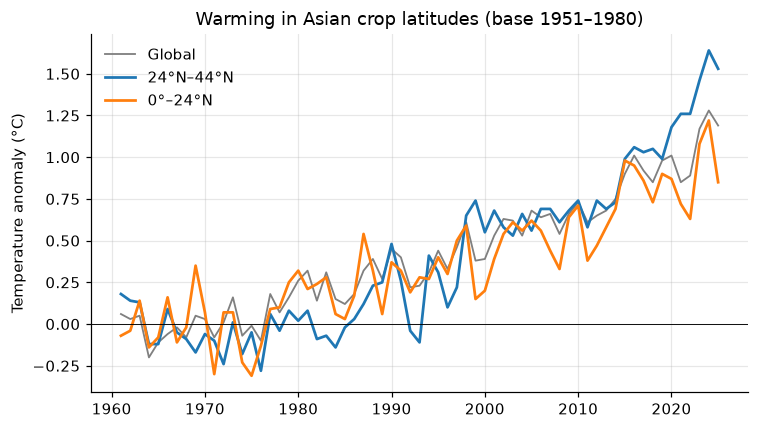

In [43]:
z = zon[zon["Year"] >= 1961]
fig, ax = plt.subplots(figsize=(7,4))
ax.plot(z["Year"], z["Glob"], color="gray", lw=1.2, label="Global")
ax.plot(z["Year"], z["24N-44N"], lw=1.8, label="24°N–44°N")
ax.plot(z["Year"], z["EQU-24N"], lw=1.8, label="0°–24°N")
ax.axhline(0, color="k", lw=0.6)
ax.set_ylabel("Temperature anomaly (°C)")
ax.set_title("Warming in Asian crop latitudes (base 1951–1980)")
ax.legend(frameon=False)
save(fig, "fig1_gistemp_zonal")

saved: fig2_detrending


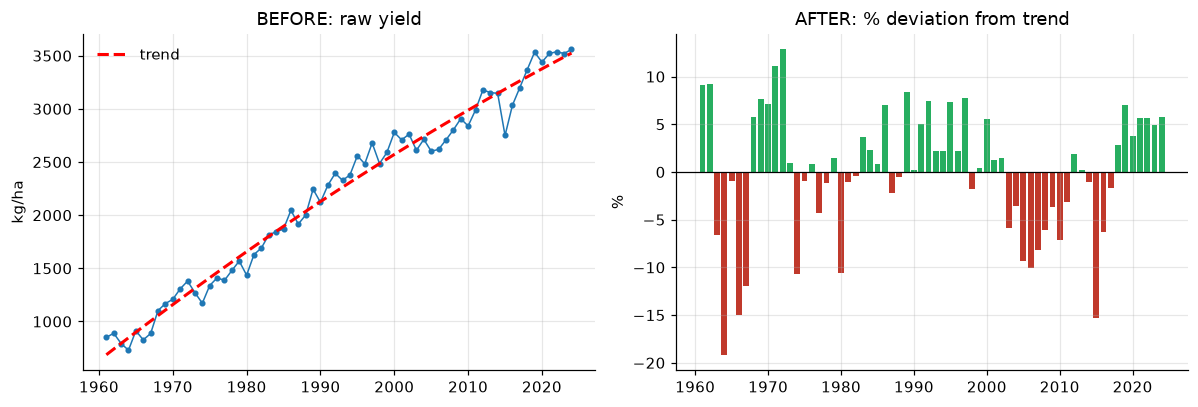

In [44]:
ex = panel_base[(panel_base.Area=="India") & (panel_base.Item=="Wheat")].sort_values("Year")
co = np.polyfit(ex.Year, ex["yield"], 2)

fig, axes = plt.subplots(1, 2, figsize=(11,3.8))
axes[0].plot(ex.Year, ex["yield"], "o-", ms=3, lw=1)
axes[0].plot(ex.Year, np.polyval(co, ex.Year), "r--", lw=2, label="trend")
axes[0].set_title("BEFORE: raw yield"); axes[0].set_ylabel("kg/ha")
axes[0].legend(frameon=False)
axes[1].bar(ex.Year, ex["yield_anom"],
            color=["#c0392b" if v<0 else "#27ae60" for v in ex["yield_anom"]])
axes[1].axhline(0, color="k", lw=0.8)
axes[1].set_title("AFTER: % deviation from trend"); axes[1].set_ylabel("%")
save(fig, "fig2_detrending")

saved: fig3_volatility


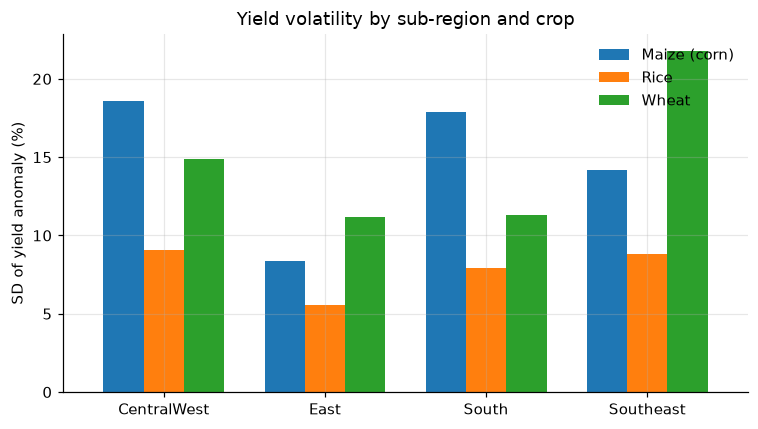

In [45]:
v = (panel.dropna(subset=["Subregion"])
     .groupby(["Subregion","Item"])["yield_anom"].std().unstack())
fig, ax = plt.subplots(figsize=(7,4))
v.plot(kind="bar", ax=ax, width=0.75, edgecolor="none")
ax.set_ylabel("SD of yield anomaly (%)"); ax.set_xlabel("")
ax.set_title("Yield volatility by sub-region and crop")
ax.legend(frameon=False); plt.xticks(rotation=0)
save(fig, "fig3_volatility")

saved: fig4_temp_vs_yield


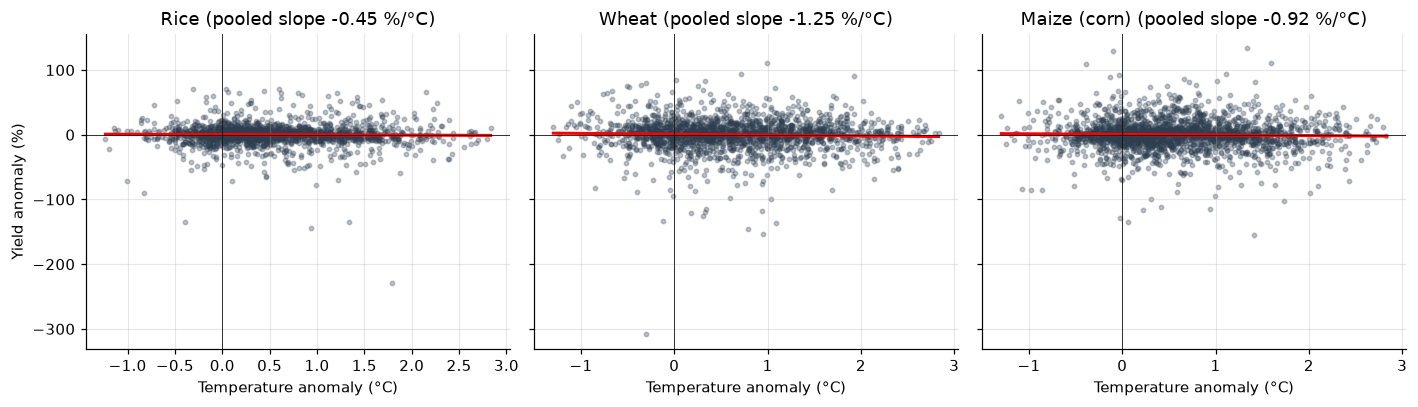

In [46]:
fig, axes = plt.subplots(1, 3, figsize=(13,3.8), sharey=True)
for ax, crop in zip(axes, CROPS):
    d = panel[panel.Item==crop].dropna(subset=["temp_anom","yield_anom"])
    ax.scatter(d.temp_anom, d.yield_anom, s=8, alpha=0.3, color="#2c3e50")
    b, a = np.polyfit(d.temp_anom, d.yield_anom, 1)
    xs = np.linspace(d.temp_anom.min(), d.temp_anom.max(), 50)
    ax.plot(xs, a + b*xs, "r-", lw=2)
    ax.axhline(0, color="k", lw=0.5); ax.axvline(0, color="k", lw=0.5)
    ax.set_title(f"{crop} (pooled slope {b:.2f} %/°C)")
    ax.set_xlabel("Temperature anomaly (°C)")
axes[0].set_ylabel("Yield anomaly (%)")
save(fig, "fig4_temp_vs_yield")

saved: fig6_eo_value


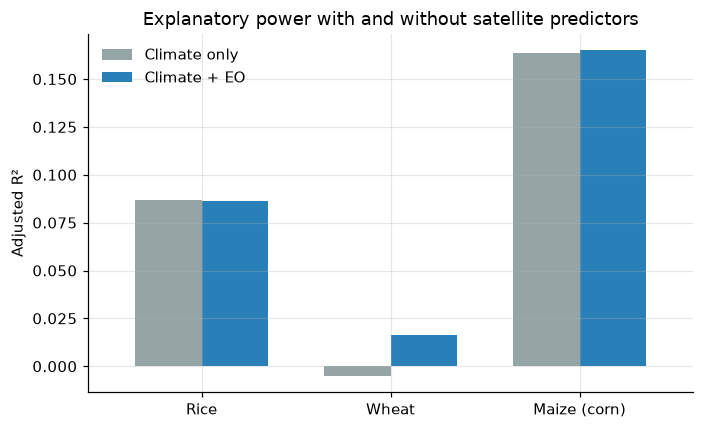

In [47]:
if len(eo_results):
    fig, ax = plt.subplots(figsize=(6.5,4))
    eo_results.set_index("crop")[["Climate only","Climate + EO"]].plot(
        kind="bar", ax=ax, width=0.7, color=["#95a5a6","#2980b9"], edgecolor="none")
    ax.set_ylabel("Adjusted R²"); ax.set_xlabel("")
    ax.set_title("Explanatory power with and without satellite predictors")
    ax.legend(frameon=False); plt.xticks(rotation=0)
    save(fig, "fig6_eo_value")

In [48]:
TAB = ROOT / "outputs" / "tables"
TAB.mkdir(parents=True, exist_ok=True)
vol.to_csv(TAB / "t1_volatility.csv", index=False)
sr_df.to_csv(TAB / "t3_subregional.csv", index=False)
eo_results.to_csv(TAB / "t4_eo.csv", index=False)
print("exported")

exported
